In [1]:
import rdata
import numpy as np
import pandas as pd

# Read the RDS file, which returns a dictionary-like structure
# r_object = rdata.read_rds('../data/predictions_cards.rds')
# df = rdata.convert(r_object, lazy=False)

In [2]:
df = pd.read_csv('../data/hospitalizations/hospitalizations_1wk.csv', index_col=0)
df = df[df.geo_value == 'us']
df.drop(columns=['geo_value'], inplace=True)
print(f"Shape: {df.shape}")

Shape: (19075, 30)


In [3]:
print(f"No actual data before 2020-07-27: {df.actual[df.target_end_date < '2020-07-27'].isna().mean()}")
print(f"No actual data after 2023-06-10: {df.actual[df.target_end_date > '2023-06-10'].isna().mean()}")

df2 = df[df.target_end_date >= '2020-07-27']
df2 = df2[df2.target_end_date <= '2023-06-10']
print("# of rows after filtering:", df2.shape)   # Actual column has no NA after this

No actual data before 2020-07-27: 1.0
No actual data after 2023-06-10: 1.0
# of rows after filtering: (18384, 30)


In [4]:
forecasters, counts = np.unique(df2.forecaster, return_counts=True)
sorted_indices = np.argsort(counts)[::-1]
sorted_forecasters = forecasters[sorted_indices]
sorted_counts = counts[sorted_indices]
list(zip(sorted_forecasters, sorted_counts))[0:10]

[('CU-select', np.int64(1043)),
 ('GT-DeepCOVID', np.int64(979)),
 ('COVIDhub_CDC-ensemble', np.int64(915)),
 ('COVIDhub-4_week_ensemble', np.int64(915)),
 ('COVIDhub-baseline', np.int64(915)),
 ('COVIDhub-ensemble', np.int64(915)),
 ('Karlen-pypm', np.int64(875)),
 ('JHU_IDD-CovidSP', np.int64(825)),
 ('MOBS-GLEAM_COVID', np.int64(803)),
 ('COVIDhub-trained_ensemble', np.int64(796))]

In [10]:
forecaster_list = ['CU-select', 'GT-DeepCOVID', 'COVIDhub_CDC-ensemble',
       'COVIDhub-4_week_ensemble', 'COVIDhub-baseline',
       'COVIDhub-ensemble', 'Karlen-pypm', 'JHU_IDD-CovidSP',
       'MOBS-GLEAM_COVID']

# Given df, take the latest forecast
def take_last_among_dup (df):
    assert all(col in df.columns for col in ['target_end_date', 'forecast_date'])
    return df.loc[df.groupby('target_end_date')['forecast_date'].idxmax()]

df_data_dic = {}

for f_name in forecaster_list:
    df_here = df2[df2.forecaster == f_name]   
    date_start = pd.to_datetime(df_here.target_end_date.min())
    date_end = pd.to_datetime(df_here.target_end_date.max())
    date_range_length = (date_end - date_start).days + 1  # inclusive of endpoints
    
    # Duplicate check 
    ud, rc = np.unique(df_here.target_end_date, return_counts=True)
    n_missing = date_range_length - len(ud)
    print(f'{f_name:>25}: Rows {df_here.shape[0]:>5}, First date: {date_start.date()}, Last date: {date_end.date()}, Missing: {n_missing}')
    missing_dates = pd.date_range(start=date_start, end=date_end).strftime('%Y-%m-%d').difference(df_here.target_end_date)
    if False:
        print(missing_dates)
    if np.sum(rc > 1) > 1:
        dup_dates = np.sort(ud[rc > 1])
        print(f"{0:>27}Contains {len(dup_dates)} duplicate forecasts from {dup_dates[0]} to {dup_dates[-1]}")
        df_here = take_last_among_dup(df_here)
    
    df_data_dic[f_name] = df_here

                CU-select: Rows  1043, First date: 2020-07-27, Last date: 2023-03-12, Missing: 28
                          0Contains 112 duplicate forecasts from 2020-08-07 to 2020-12-31
             GT-DeepCOVID: Rows   979, First date: 2020-07-27, Last date: 2023-06-10, Missing: 70
    COVIDhub_CDC-ensemble: Rows   915, First date: 2020-12-08, Last date: 2023-06-10, Missing: 0
 COVIDhub-4_week_ensemble: Rows   915, First date: 2020-12-08, Last date: 2023-06-10, Missing: 0
        COVIDhub-baseline: Rows   915, First date: 2020-12-08, Last date: 2023-06-10, Missing: 0
        COVIDhub-ensemble: Rows   915, First date: 2020-12-08, Last date: 2023-06-10, Missing: 0
              Karlen-pypm: Rows   875, First date: 2020-07-27, Last date: 2023-02-26, Missing: 70
          JHU_IDD-CovidSP: Rows   825, First date: 2020-07-27, Last date: 2023-06-10, Missing: 226
                          0Contains 2 duplicate forecasts from 2021-08-23 to 2022-08-22
         MOBS-GLEAM_COVID: Rows   803, Fi

### Y and impute based on past Y

In [19]:
import scipy.stats as stats

g = df2.groupby("target_end_date")["actual"]

result = pd.DataFrame({
    "actual": g.first(),                       # candidate value
    "any_na": g.apply(lambda x: x.isna().any()),
    "n_unique_non_na": g.nunique(dropna=True)  # number of unique actual values
})

result["all_equal"] = result["n_unique_non_na"] == 1
result["valid"] = (~result["any_na"]) & (result["all_equal"])
print(f'Start date: {result.index.min()}, End date: {result.index.max()}, # of dates in data: {result.shape[0]}')
print(f'Total dates: {(pd.to_datetime(result.index.max()) - pd.to_datetime(result.index.min())).days + 1}')
print(f'Not valid dates: {result.shape[0] - result["valid"].sum()}')


alpha_list = [float(col[10:]) for col in df2.columns if col.startswith('forecast_0')]
Y = result['actual'].sort_index()
Y_7days_delay = Y.shift(7).fillna(0)
Y_7days_std = Y.rolling(7).std().shift(7).fillna(0) # Using 7 days std that's most recent in 7 days ago
Y_impute = {}
for alpha in alpha_list:
    Y_impute[alpha] = Y_7days_delay + Y_7days_std * stats.norm.ppf(alpha)

Start date: 2020-07-27, End date: 2023-06-10, # of dates in data: 1049
Total dates: 1049
Not valid dates: 0


In [29]:
df3.groupby('target_end_date').size() != len(f_list)

target_end_date
2020-07-27    True
2020-07-28    True
2020-07-29    True
2020-07-30    True
2020-07-31    True
              ... 
2023-06-06    True
2023-06-07    True
2023-06-08    True
2023-06-09    True
2023-06-10    True
Length: 1049, dtype: bool

In [31]:
f_list = ['COVIDhub-baseline', 'COVIDhub-ensemble', \
            'CU-select', 'GT-DeepCOVID', 'Karlen-pypm', 'JHU_IDD-CovidSP']    #  'COVIDhub-4_week_ensemble' is same as 'COVIDhub-ensemble' and 'COVIDhub_CDC-ensemble' is almost similar
df_covidhub = df_data_dic['COVIDhub-baseline']
covidhub_date_range = pd.date_range(start=df_covidhub.target_end_date.min(), end=df_covidhub.target_end_date.max())

df3 = pd.concat([df_data_dic[f_name] for f_name in f_list])

is_data_missing = df3.groupby('target_end_date').size() != len(f_list)
print('Days with missing forecasts:', np.sum(is_data_missing))    
print(is_data_missing[~is_data_missing])

# For weekely data
# print(df3.groupby('forecast_date').size())
# print('Days with missing forecasts:', np.sum(df3.groupby('forecast_date').size() != 28))    
# df3 = df3[df3.forecast_date != '2023-06-05']
# print('Days with missing forecasts (after removing 2023-06-05):', np.sum(df3.groupby('forecast_date').size() != 28))

Days with missing forecasts: 505
target_end_date
2020-12-08    False
2020-12-09    False
2020-12-10    False
2020-12-11    False
2020-12-12    False
              ...  
2023-02-22    False
2023-02-23    False
2023-02-24    False
2023-02-25    False
2023-02-26    False
Length: 544, dtype: bool


In [ ]:
# Date map - maybe not needed, Need similar version for weeekly data
date_diff = (covidhub_date_range - covidhub_date_range[0]).days
date_map = {}
date_map_r = {}
for date, diff in zip(covidhub_date_range, date_diff):
    date_map[date.strftime('%Y-%m-%d')] = diff
    date_map_r[diff] = date.strftime('%Y-%m-%d')

In [ ]:
print('Target date with NA actual: ', np.sum(df3.groupby('target_end_date')['actual'].apply(lambda x: x.isna().any())))
print('Target date with non-zero std (across different forecasters): ', np.sum(df3.groupby('target_end_date').actual.std() > 0))

df4 = df3.drop(columns=['ahead', 'forecast_date', 'forecast_NaN'])

forecasts_dict = {}
alpha_list = [float(col[10:]) for col in df4.columns if col.startswith('forecast_0')]
dates_list = covidhub_date_range.strftime('%Y-%m-%d')

for forecaster in f_list:
    forecasts_dict[f'{forecaster}'] = {}
    for alpha in alpha_list:
        forecasts_dict[f'{forecaster}'][alpha] = (df4.loc[df4['forecaster'] == forecaster, [f'forecast_{alpha}', 'target_end_date']]
                                                .set_index('target_end_date')[f'forecast_{alpha}']
                                                .reindex(dates_list)
                                                .fillna(Y_impute[alpha])
                                                )
        
# Weekly aggregate
# df4 = df3.drop(columns=['ahead', 'target_end_date', 'forecast_NaN']).groupby(['forecaster', 'forecast_date'], as_index=False).sum()
# Y = {date: df4.loc[df4['forecast_date'] == date, 'actual'].values[0] for date in sorted(df4['forecast_date'].unique())}

Target date with NA actual:  0
Target date with non-zero std (across different forecasters):  0


In [280]:
print(alpha_list)

[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]


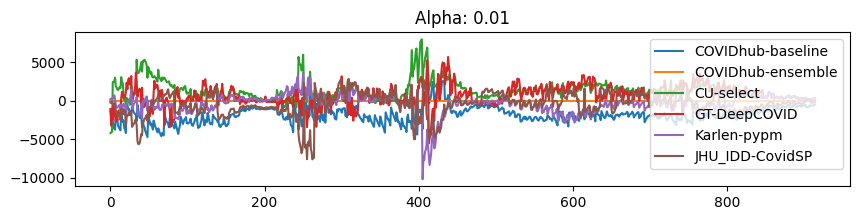

In [34]:
import matplotlib.pyplot as plt

for alpha in alpha_list:
    plt.figure(figsize=(10, 2))
    for forecaster in f_list:
        plt.plot(np.arange(len(forecasts_dict[f'{forecaster}'][alpha])), 
        forecasts_dict[f'{forecaster}'][alpha]  - forecasts_dict[f'COVIDhub-ensemble'][alpha], label=forecaster) #
    plt.legend()
    plt.title(f'Alpha: {alpha}')
    plt.show()
    break

In [35]:
pd.Series(Y).max() # -> unit as 100

np.float64(23473.0)

In [48]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Callable, Tuple
import importlib
import metrics
import multi_q_minmax_solver
importlib.reload(metrics)
importlib.reload(multi_q_minmax_solver)
from metrics import pinball_loss, create_scoring_function_class
from multi_q_minmax_solver import multi_q_minmax_solver, minimax_value_neg


def omni_error_from_scores(scores: np.ndarray):
    # scores: (T, N, m, ..)
    # return: (T, ..)
    if scores.ndim == 3:
        return np.max(scores.cumsum(axis=0), axis=(1,2)) / (np.arange(scores.shape[0]) + 1)
    elif scores.ndim == 4:
        return np.max(scores.cumsum(axis=0), axis=(1,2)) / (np.arange(scores.shape[0])[:, None] + 1)
    else:
        raise ValueError(f"scores.ndim: {scores.ndim}")



# ============================================================================
# Main Omniprediction Experiment
# ============================================================================

# maybe to add unit size and flexible Y range here. Something like if Y value that is higher than current range of Y, add more \theta_is and put some weights there. (Should prove if we still have same Hedge performance bound)
def omniprediction_multiq_online(Y: pd.Series, forecasts_dict: dict, Y_max_padding:float = None, unit: int = 100, m: int = 10, 
                                alpha_list: List[float] = [0.5], eta_multiplier: float = 1,
                                eta_f_multiplier: float = 1, seed: int = 42):
    """
    Run omniprediction experiment and compare against base forecasters.
    
    Parameters
    ----------
    T : int
        Time horizon / number of samples
    m : int
        Number of discretized theta values
    F : int
        Number of base forecasters
    alpha_list : List[float]
        List of quantile levels
    eta : float
        Learning rate for weights w_i
    eta_f : float
        Learning rate for forecaster selection v_{i,j}
    seed : int
        Random seed
    
    Returns
    -------
    results : dict
        Dictionary containing all results
    """
    print("="*70)
    print("OMNIPREDICTION MULTI-QUANTILE EXPERIMENT")
    print("="*70)
    
    np.random.seed(seed)

    
    ###########################
    # NO-X ONLINE PART
    ###########################
    # Import Y and base forecasters
    dates_list = sorted(Y.index)
    T = len(dates_list)
    Y_rounded_min = min(int(np.floor(Y.values.min() / unit)), 0)
    Y_rounded_max = int(np.ceil((Y.values.max() + (Y_max_padding if Y_max_padding else Y.values.max()*0.1)) / unit))
    m = Y_rounded_max - Y_rounded_min
    thetas = np.arange(Y_rounded_min, Y_rounded_max) + 0.5
    F = len(forecasts_dict.keys())
    forecaster_names = list(forecasts_dict.keys())

    alpha_list = np.array(alpha_list)
    assert len(alpha_list.shape) == 1
    N = alpha_list.shape[0]
    
    # Create scoring function class S_alpha
    scoring_functions, _ = create_scoring_function_class(
        alpha_list=alpha_list,
        thetas=thetas
    )    

    eta = eta_multiplier * np.sqrt(np.log(m)/T)
    eta_f = eta_f_multiplier * np.sqrt(np.log(F)/T)

    for forecaster in forecaster_names:
        for alpha in alpha_list:
            if alpha not in forecasts_dict[forecaster].keys():
                raise ValueError(f"alpha {alpha} not in forecasts_dict[{forecaster}].keys()")
            assert set(forecasts_dict[forecaster][alpha].index) == set(Y.index), f'forecasts_dict[forecaster][alpha].index: {forecasts_dict[forecaster][alpha].index}, Y.index: {Y.index}'

    Y = (Y/unit).round(decimals=0).copy()
    forecasts_dict_rounded = {}
    for forecaster in forecaster_names:
        forecasts_dict_rounded[forecaster] = {}
        for alpha in alpha_list:
            forecasts_dict_rounded[forecaster][alpha] = (forecasts_dict[forecaster][alpha] / unit).round(decimals=0)
            
    all_forecaster_preds_all_dates = np.array([
        [
            [
                forecasts_dict_rounded[forecaster][alpha][date] 
                for forecaster in forecaster_names
            ] 
            for alpha in alpha_list
        ]
        for date in dates_list
    ])   # shape (T, N, F)

    print(f"\nData:")
    print(f"  Number of dates: {T}")
    print(f"  Y range: [{min(Y.values):.3f}, {max(Y.values):.3f}]")
    print(f"  Unit size: {unit}")
    print(f"  Number of discretized thetas: {m}")
    print(f"  Number of base forecasters: {F}")
    print(f"  Forecaster names: {forecaster_names}")
    print(f"  Quantile level: alpha = {alpha_list} ({len(alpha_list)} levels)")
    
    ###########################


    # Initialize algorithm state
    w = np.ones((N, m)) / (N*m)  # Uniform weights over thetas
    v = np.ones((N, m, F)) / F  # Uniform weights over forecasters for each theta
    f_selected_indices = np.zeros((N, m), dtype=np.int32)  # Initially all use first forecaster
    
    pinball_v = np.ones((N,F)) / F  # each quantilie level separately
    pinball_f_selected_indices = np.zeros(N, dtype=np.int32)
    ql_v = np.ones(F) / F  # all quantile levels together
    ql_f_selected_index = 0
    
    # Storage for regrets over time
    y_arr = np.array(Y.values)
    phat_history = np.zeros((T, N))
    w_history = np.zeros((T, N, m))
    v_history = np.zeros((T, N, m, F))
    minimax_value_history = np.zeros((T,))
    omni_error_history = np.zeros((T, N, m))
    preds_history = np.zeros((T, N, F))     # Predictions of each forecaster
    forecasters_score_history = np.zeros((T, N, m, F))
    forecasters_selection_history = np.zeros((T, N, m))

    pinball_selection_history = np.zeros((T, N))
    pinball_preds_history = np.zeros((T, N))
    ql_selection_history = np.zeros((T))
    ql_preds_history = np.zeros((T, N))
    
    print(f"\nRunning omniprediction algorithm...")
    
    for t, date in tqdm(enumerate(dates_list)):
        # x_t = X[t]
        y_t = Y[date]
        
        # Step 1: Compute P_t
        all_forecaster_preds = all_forecaster_preds_all_dates[t,:,:]
        
        # Select one forecaster per theta level (currently using index)
        # Use advanced NumPy indexing for compactness and speed
        row_idx = np.arange(N)[:, None]
        col_idx = f_selected_indices
        # print(row_idx)
        # print(col_idx)
        forecaster_preds = all_forecaster_preds[row_idx, col_idx]
        assert forecaster_preds.shape == (N, m)


        phat_dict_list, Vn_values = multi_q_minmax_solver(
            theta_weights=w,
            thetas=thetas,
            forecast_values=forecaster_preds,
        )
        minimax_value_history[t] = minimax_value_neg(alpha_list=alpha_list, Vn_values=Vn_values)

        phat = np.array([phat_dict["phat"] for phat_dict in phat_dict_list])
        phat_history[t,:] = phat
        k_star = np.array([phat_dict["k_star"] for phat_dict in phat_dict_list])
        k_star_prob = np.array([phat_dict["k_star_prob"] for phat_dict in phat_dict_list])
        
        # Step 2: Compute expected score under P_t
        phat_score = np.stack([
            k_star_prob[n] * np.array([S(k_star[n]/m, y_t) for S in scoring_functions[n]]) +
            (1-k_star_prob[n]) * np.array([S((k_star[n]+1)/m, y_t) for S in scoring_functions[n]])
            for n in range(N)
        ])
        f_selected_score = np.stack([
            np.array([S(forecaster_preds[n,i], y_t) for i, S in enumerate(scoring_functions[n])])
            for n in range(N)
        ])
        
        assert phat_score.shape == (N, m), f'phat_score.shape: {phat_score.shape}, N: {N}, m: {m}'
        assert f_selected_score.shape == (N, m), f'f_selected_score.shape: {f_selected_score.shape}, N: {N}, m: {m}'
        
        # Step 3: Update weights w_i
        w_history[t,:] = w
        v_history[t,:,:] = v
        log_w = np.log(w + 1e-10)
        log_w += eta * (phat_score - f_selected_score)
        
        # Normalize in log space
        max_log_w = np.max(log_w)
        log_w -= max_log_w
        w = np.exp(log_w)
        w /= np.sum(w)
        
        # Step 4: Update forecaster selection v_{i,j} (vectorized implementation)
        preds = all_forecaster_preds    # (N, F)
        preds_history[t,:, :] = preds
        # Fix TypeError: list indices must be integers or slices, not tuple
        scores = np.stack([
            np.stack([
                [scoring_functions[n][i](preds[n, j], y_t) for j in range(F)]
                for i in range(m)
            ])
            for n in range(N)
        ])
        assert scores.shape == (N, m, F)
        
        log_v = np.log(v + 1e-10)
        log_v -= eta_f * scores
        
        # Normalize in log-space for numerical stability
        max_log_v = np.max(log_v, axis=2, keepdims=True)
        log_v -= max_log_v
        
        v = np.exp(log_v)
        v /= np.sum(v, axis=2, keepdims=True)
        
        # Step 4-2: Hedge algorithm using pinball loss
        # Store selection history in vectorized manner
        pinball_selection_history[t, :] = pinball_f_selected_indices
        pinball_preds_history[t, :] = preds[np.arange(N), pinball_f_selected_indices]
        
        # Vectorized pinball loss computation and update
        # Compute pinball losses for all (N, F) at once
        pinball_losses = pinball_loss(preds, y_t, alpha_list[:, None])  # expects broadcasting: preds (N, F), alpha_list (N,1) -> (N,F)
        assert pinball_losses.shape == (N, F)

        # Vectorized update of pinball_v (N,F)
        pinball_v = np.log(pinball_v + 1e-10)
        pinball_v -= eta_f * pinball_losses
        pinball_v -= np.max(pinball_v, axis=1, keepdims=True)
        pinball_v = np.exp(pinball_v)
        pinball_v /= np.sum(pinball_v, axis=1, keepdims=True)

        # Vectorized forecaster selection for all n at once
        # Use cumulative sums for np.random.choice efficiency
        cum_v = np.cumsum(pinball_v, axis=1)
        r = np.random.rand(N, 1)
        pinball_f_selected_indices = (cum_v > r).argmax(axis=1)



        # Step 4-3: Hedge algorithm using QL loss
        ql_selection_history[t] = ql_f_selected_index
        ql_preds_history[t,:] = preds[:, ql_f_selected_index]
        ql_loss = np.mean(pinball_losses, axis=0)
        ql_v = np.log(ql_v + 1e-10)
        ql_v -= eta_f * ql_loss
        ql_v -= np.max(ql_v)
        ql_v = np.exp(ql_v)
        ql_v /= np.sum(ql_v)
        ql_f_selected_index = np.random.choice(F, p=ql_v)


        # Step 5: Sample new forecasters
        for n in range(N):
            for i in range(m):
                j_ni = np.random.choice(F, p=v[n,i,:])
                f_selected_indices[n,i] = j_ni
    
        # Compute regret at time t
        forecasters_selection_history[t,:,:] = f_selected_indices
        forecasters_score_history[t,:,:,:] = scores
        omni_error_history[t,:,:] = np.stack([[S(phat[n], y_t) for S in scoring_functions[n]] for n in range(N)])
    
    print(f"\n" + "="*70)
    print("RESULTS")
    print("="*70)
    
    # print(f"\nOmniprediction error (from learned P):")
    # print(f"  sup_{{S in S_alpha}} E[S(P(X), Y)] = {omni_error:.6f}")
    
    # # Compute regret of each base forecaster
    # print(f"\nRegret of each base forecaster:")
    # print(f"  sup_{{S in S_alpha}} E[S(f_j(X), Y)]")

    omni_score_trace = omni_error_from_scores(omni_error_history)
    assert omni_score_trace.shape == (T,)

    forecasters_score_trace = omni_error_from_scores(forecasters_score_history)
    assert forecasters_score_trace.shape == (T, F)

    best_forecaster_score_trace = forecasters_score_trace.min(axis=1)
    
    # Theoretical bound
    # theoretical_bound = np.sqrt(np.log(m * F) / T)
    # print(f"\nTheoretical omniprediction guarantee:")
    # print(f"  O(sqrt(log(m*F)/T)) = O(sqrt({np.log(m*F):.2f}/{T}))")
    # print(f"                      = O({theoretical_bound:.6f})")
    
    # Return results
    return {
        'phat_history': phat_history,
        'w_history': w_history,
        'v_history': v_history,
        'minimax_value_history': minimax_value_history, # (T,)
        'omni_error_history': omni_error_history,   # (T, N, m) 
        'forecasters_preds_history': preds_history, # (T, N, F)
        'forecasters_score_history': forecasters_score_history, # (T, N, m, F)
        'forecasters_selection_history': forecasters_selection_history, # (T, N, m)
        'omni_score_trace': omni_score_trace,   # (T,)
        'forecasters_score_trace': forecasters_score_trace, # (T, F)    
        'best_forecaster_score_trace': best_forecaster_score_trace, # (T,)
        'thetas': thetas,
    
        'pinball_selection_history': pinball_selection_history,     # (T, N)
        'pinball_preds_history': pinball_preds_history,             # (T, N)
        'ql_selection_history': ql_selection_history,               # (T,)
        'ql_preds_history': ql_preds_history,                       # (T, N)
        
        'Y': Y,
        'y_arr': y_arr,
        'dates_list': dates_list,
        # 'X': X,
        'T': T,
        'unit': unit,
        'm': m,
        'F': F,
        'alpha_list': alpha_list,
        'forecaster_names': forecaster_names,
        # 'theoretical_bound': theoretical_bound,
    }


In [49]:
print(alpha_list)

[0.01, 0.025, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.975, 0.99]


In [51]:
# ============================================================================
# Run Experiment
# ============================================================================

alpha_list_here = np.array([0.05, 0.3, 0.5, 0.7, 0.95])
results = omniprediction_multiq_online(Y=Y[dates_list], forecasts_dict=forecasts_dict, unit=100, alpha_list=alpha_list_here)
print("\n" + "="*70)
print("Experiment complete!")
print("="*70)

OMNIPREDICTION MULTI-QUANTILE EXPERIMENT

Data:
  Number of dates: 915
  Y range: [9.000, 235.000]
  Unit size: 100
  Number of discretized thetas: 259
  Number of base forecasters: 6
  Forecaster names: ['COVIDhub-baseline', 'COVIDhub-ensemble', 'CU-select', 'GT-DeepCOVID', 'Karlen-pypm', 'JHU_IDD-CovidSP']
  Quantile level: alpha = [0.05 0.3  0.5  0.7  0.95] (5 levels)

Running omniprediction algorithm...


915it [00:54, 16.78it/s]



RESULTS

Experiment complete!


In [52]:
pinball_preds_history = results['pinball_preds_history']    # (T, N)
ql_preds_history = results['ql_preds_history']              # (T, N)
Y_arr = results['y_arr']
m = results['m']
T = results['T']
N = alpha_list_here.shape[0]
thetas = results['thetas']

scoring_functions, thetas = create_scoring_function_class(
    alpha_list=alpha_list_here,
    thetas=thetas
)

pinball_scores = np.stack([
                        np.stack([
                            [scoring_functions[n][j](pinball_preds_history[t, n], Y_arr[t]) for j in range(m)]
                            for n in range(N)
                        ])
                        for t in range(T)
                    ])
pinball_omni_score_trace = np.max(np.cumsum(pinball_scores, axis=0), axis=(1,2)) / np.arange(1, T+1)

ql_scores = np.stack([
                        np.stack([
                            [scoring_functions[n][j](ql_preds_history[t, n], Y_arr[t]) for j in range(m)]
                            for n in range(N)
                        ])
                        for t in range(T)
                    ])
ql_omni_score_trace = np.max(np.cumsum(ql_scores, axis=0), axis=(1,2)) / np.arange(1, T+1)

/var/folders/ph/sy2dklf10vj61gx7m16k6psr0000gn/T/ipykernel_44853/3633363562.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  ax.plot(dates_list, [np.minimum(np.sqrt(np.log(results['m'] * results['F']) / t), 1.0) for t in np.arange(results['T'])], '--', label='Theoretical bound')


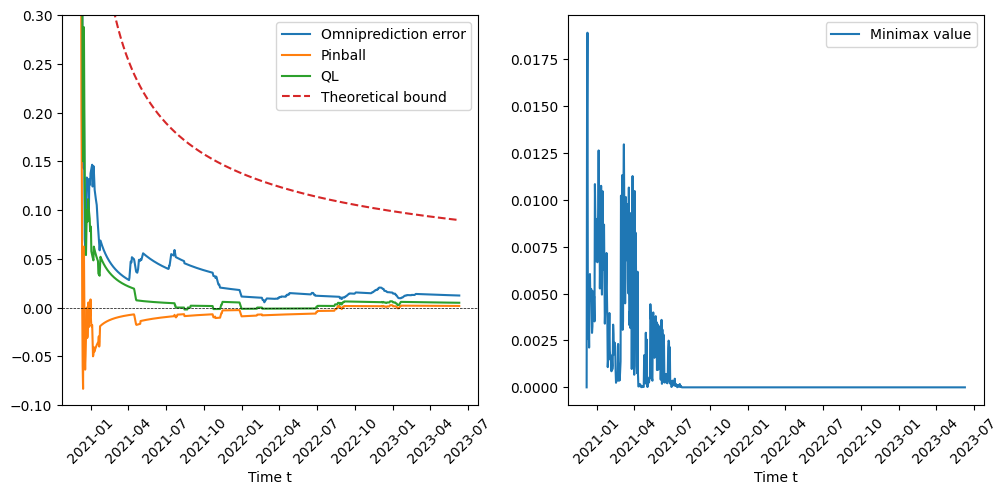

In [90]:
def simple_plot(results: dict):
    """Plot omniprediction experiment results."""
    dates_list = pd.to_datetime(results['dates_list'])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    ax = axes[0]
    ax.plot(dates_list, results['omni_score_trace'] - results['best_forecaster_score_trace'], label='Omniprediction error')
    # ax.plot(dates_list, results['best_forecaster_score_trace'], label='Best forecaster')
    ax.plot(dates_list, pinball_omni_score_trace - results['best_forecaster_score_trace'], label='Pinball')
    ax.plot(dates_list, ql_omni_score_trace - results['best_forecaster_score_trace'], label='QL')
    ax.plot(dates_list, [np.minimum(np.sqrt(np.log(results['m'] * results['F']) / t), 1.0) for t in np.arange(results['T'])], '--', label='Theoretical bound')
    ax.set_xlabel('Time t')
    ax.tick_params(axis='x', labelrotation=45)
    ax.legend()

    ax = axes[1]
    ax.plot(dates_list, results['minimax_value_history'], label='Minimax value')
    ax.set_xlabel('Time t')
    ax.tick_params(axis='x', labelrotation=45)
    ax.legend()

    return fig, axes

fig, axes = simple_plot(results)
fig.tight_layout()
axes[0].set_ylim(-0.1, 0.3)
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')

# # single_q version
# singleq_omni_score_trace_list = []
# for alpha in alpha_list_here:
#     singleq_omni_score_trace_list.append(results_dict[alpha]['omni_score_trace'])
# singleq_df = np.stack(singleq_omni_score_trace_list, axis=1)    # (T, F)
# singleq_omni_trace = singleq_df.max(axis=1)
# axes[0,0].plot(np.arange(T), singleq_omni_trace, label='SingleQ')
# axes[0,0].legend()


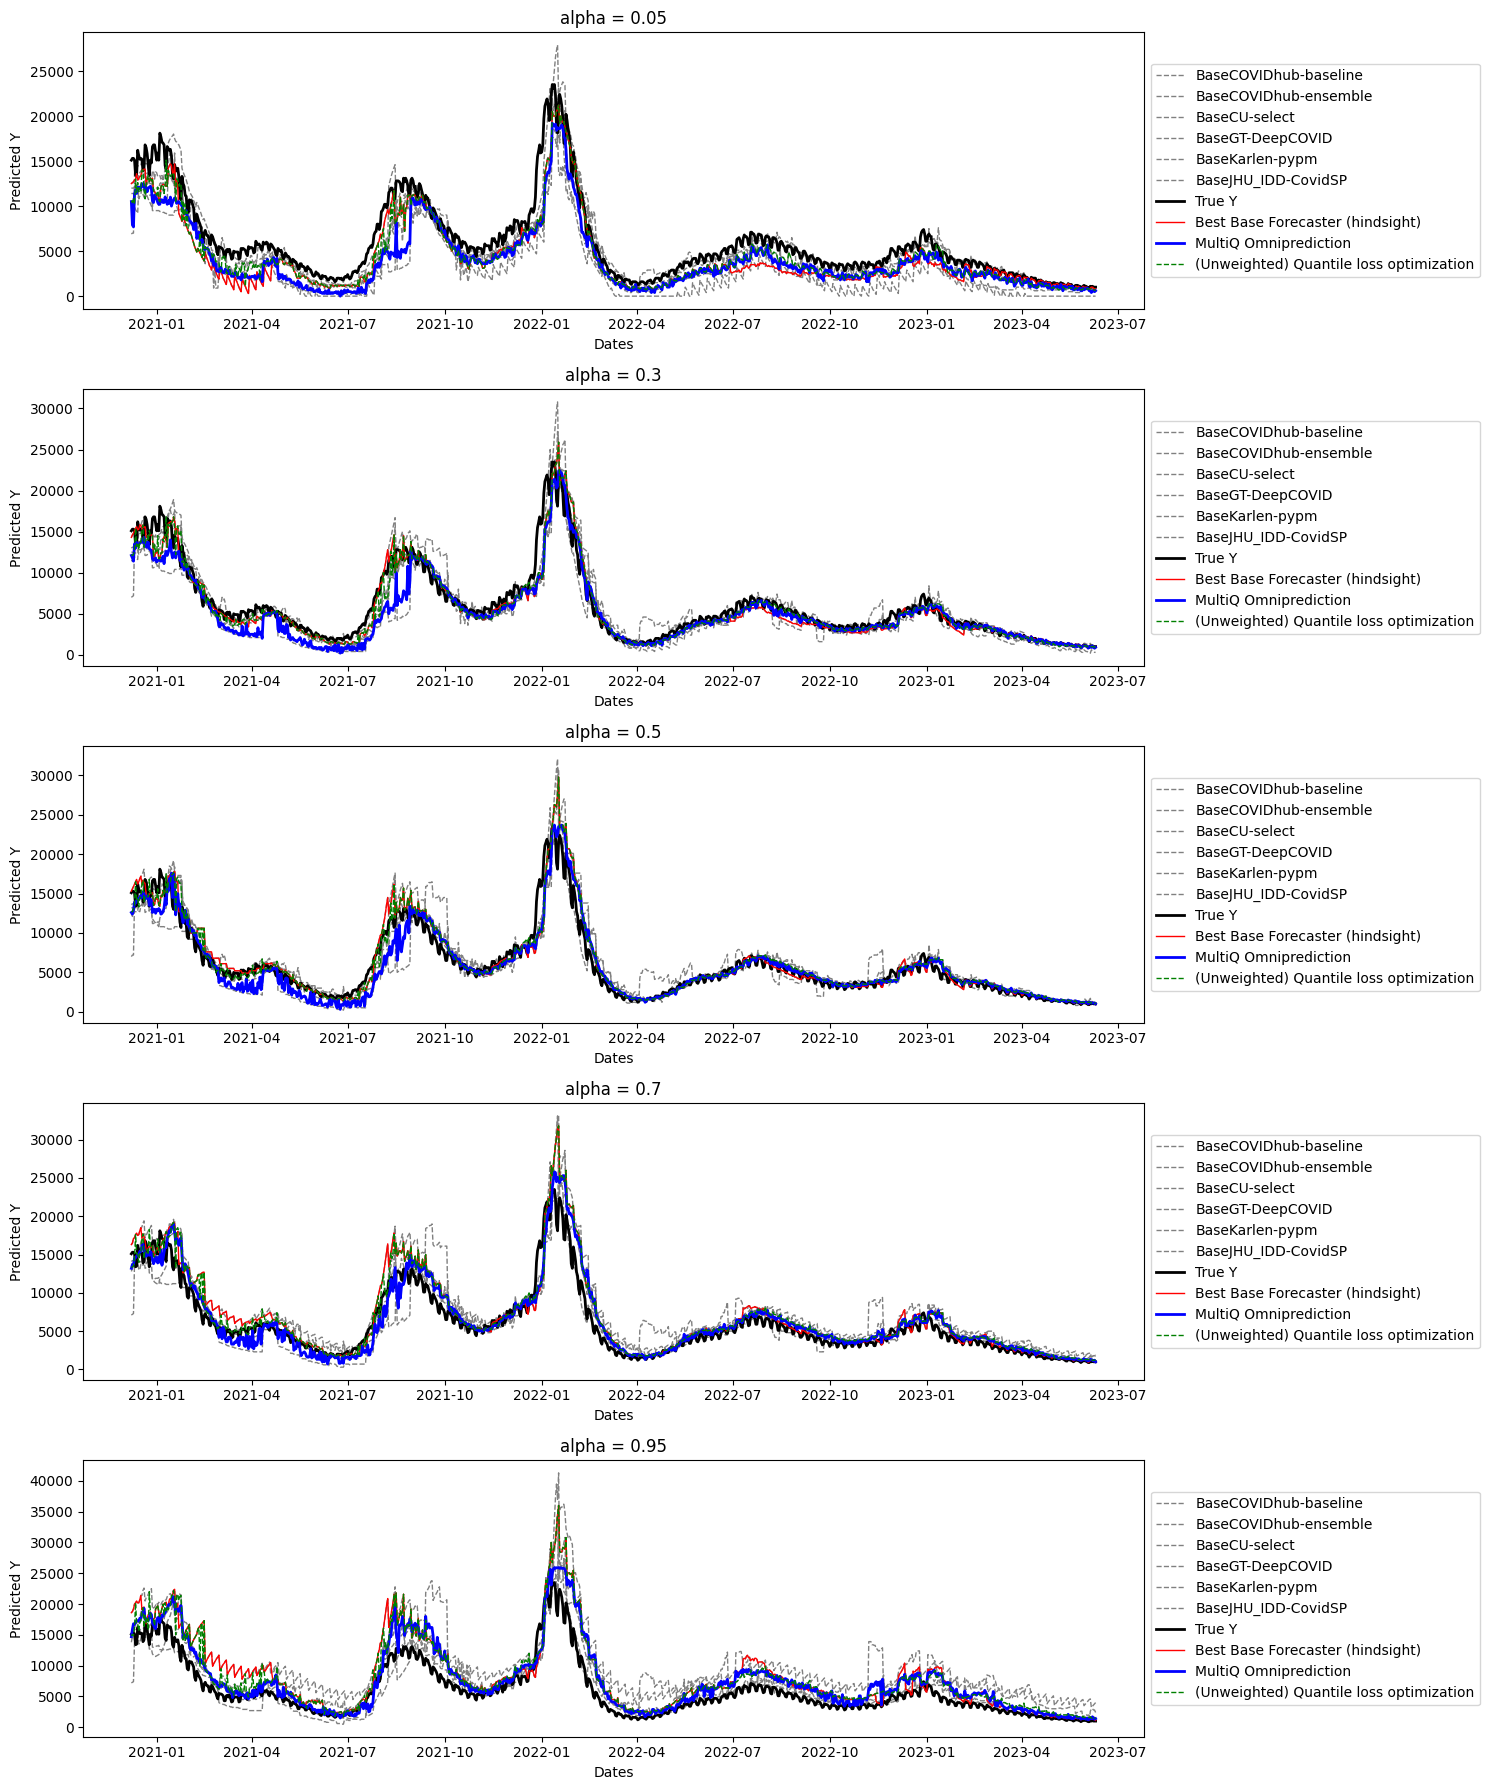

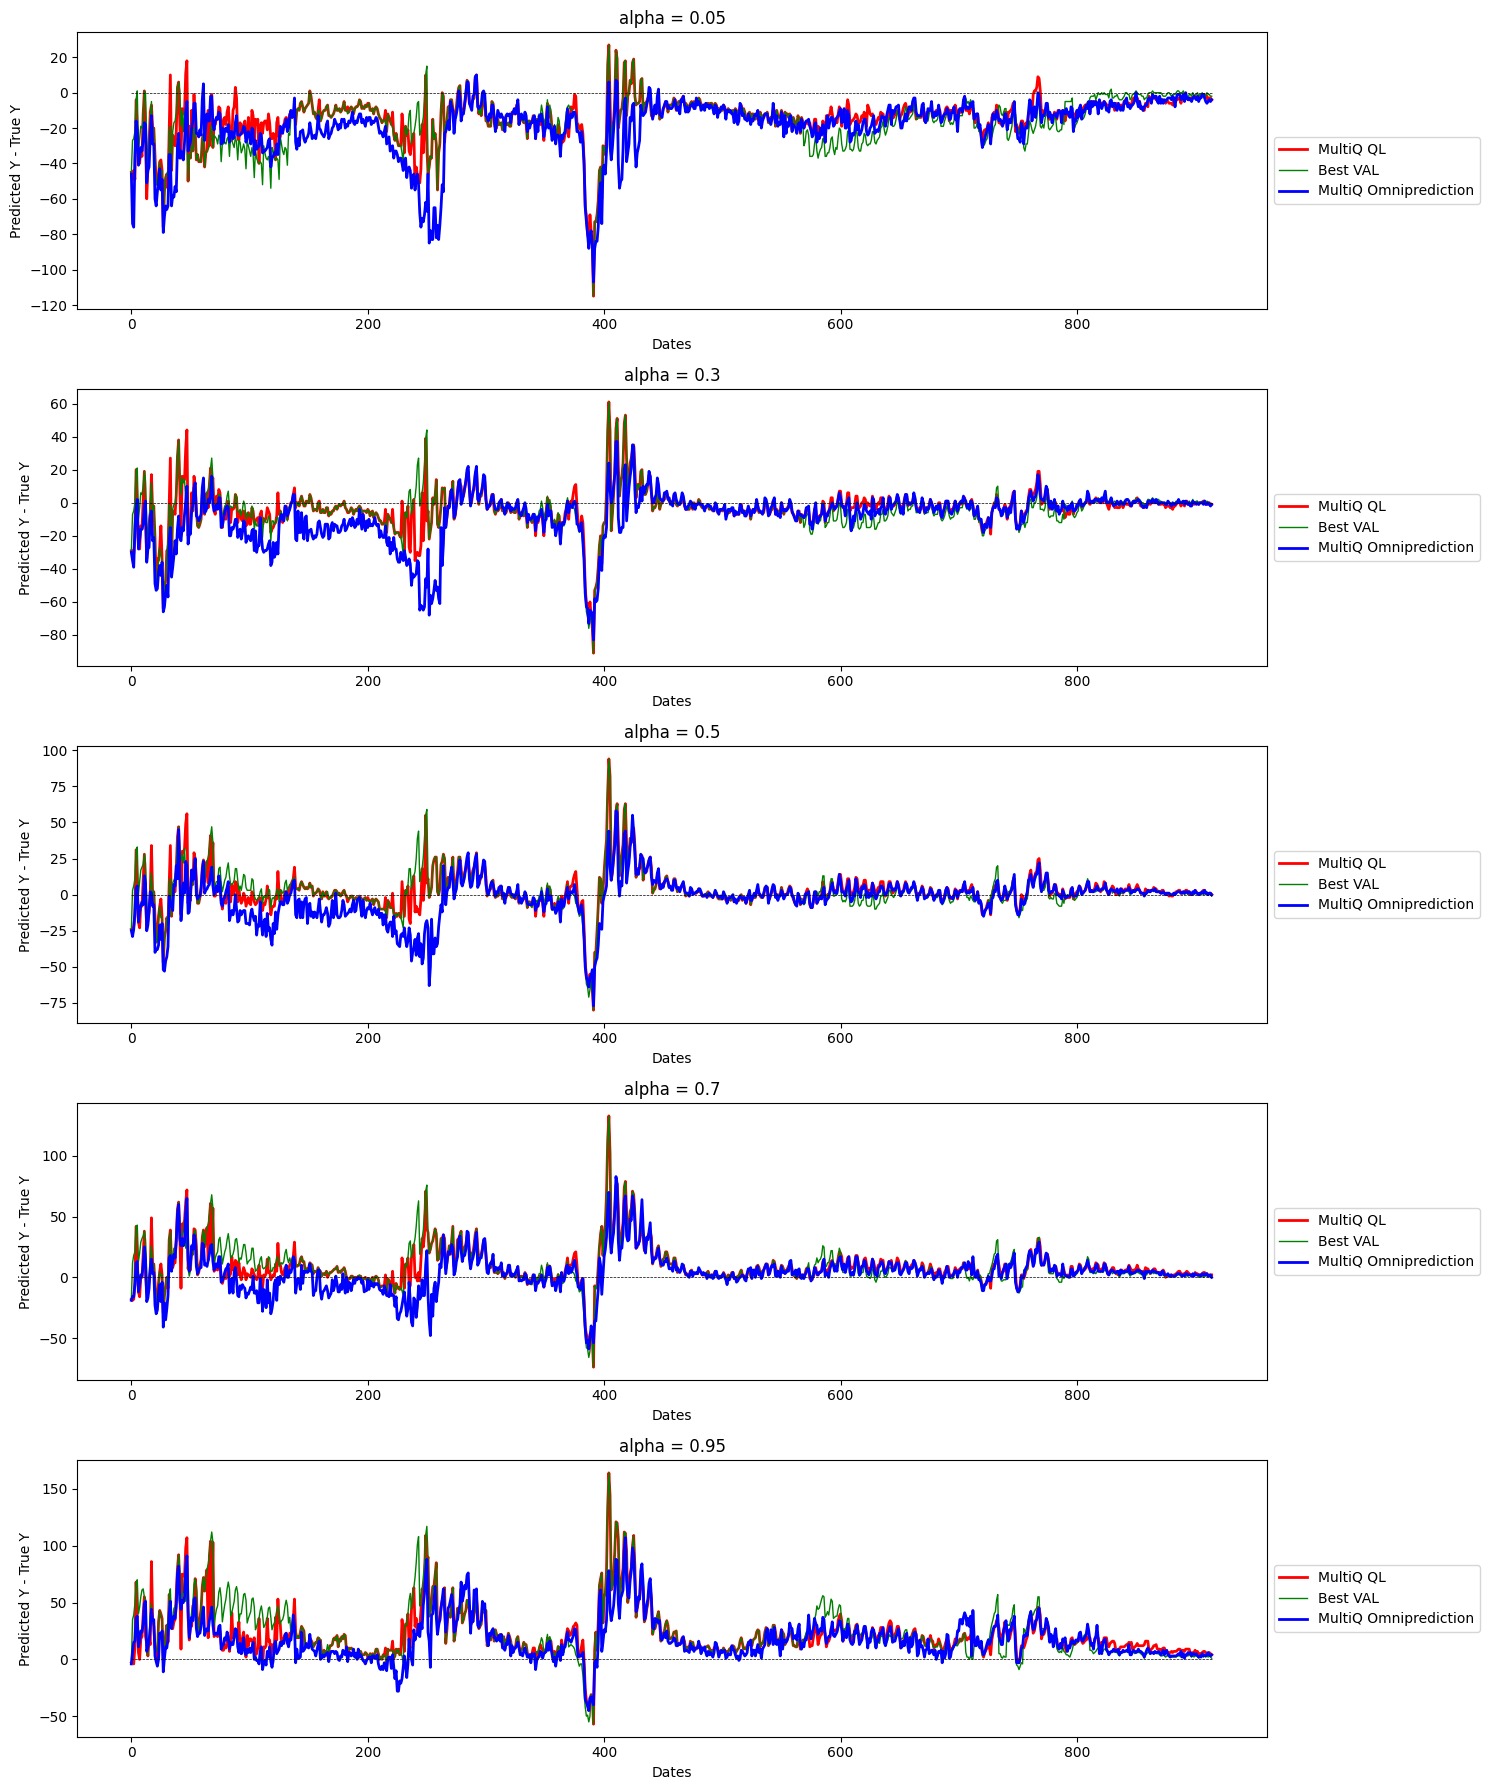

In [76]:
import pandas as pd
import scipy.stats as stats

Y_arr = results['y_arr']    # (T, )
F = results['F']
unit = results['unit']
phat_history = results['phat_history']    # (T, N)
forecasters_preds_history = results['forecasters_preds_history']    # (T, N, F)
forecaster_names = results['forecaster_names']
pinball_preds_history = results['pinball_preds_history']
ql_preds_history = results['ql_preds_history']
dates_list = pd.to_datetime(results['dates_list'])

# Best Value
forecasters_score_trace = results['forecasters_score_trace']   # (T, F)
best_val_forecaster = np.concatenate([[0], np.argmin(forecasters_score_trace, axis=1)[:-1]])   # [0] as padding to look one step before
best_val_forecaster_error = forecasters_score_trace[np.arange(T), best_val_forecaster]
best_val_forecaster_preds = forecasters_preds_history[np.arange(T), :, best_val_forecaster]

best_test_forecaster = np.argmin(forecasters_score_trace, axis=1)
best_test_forecaster_error = forecasters_score_trace[np.arange(T), best_test_forecaster]     # (T, )
best_test_forecaster_preds = forecasters_preds_history[np.arange(T), :, best_test_forecaster]   # (T, N)


def plot_prediction_panel(df, ia, alpha, relative, dates_list, unit, forecasters_preds_history, forecaster_names, F, Y_arr, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(18, 10))
    if not relative:
        for f in range(F):
            ax.plot(dates_list, unit*forecasters_preds_history[:, ia, f], color='gray', linewidth=1, linestyle='--', label=f'Base{forecaster_names[f]}')
        ax.plot(dates_list, unit*Y_arr, color='black', linewidth=2, label='True Y')
        ax.plot(dates_list, unit*df[f'best_test_pred'], color='red', linewidth=1, label='Best Base Forecaster (hindsight)')
        ax.plot(dates_list, unit*df['phat'], color='blue', linewidth=2, label='MultiQ Omniprediction')
        ax.plot(dates_list, unit*df[f'ql_pred'], color='green', linewidth=1, linestyle='--', label='(Unweighted) Quantile loss optimization')
        ax.set_ylabel('Predicted Y')
    else:
        ax.plot(np.arange(df.shape[0]), df[f'ql_pred'] - Y_arr, color='red', linewidth=2, label='MultiQ QL')
        ax.plot(np.arange(df.shape[0]), df[f'best_val_pred'] - Y_arr, color='green', linewidth=1, label='Best VAL')
        ax.plot(np.arange(df.shape[0]), df['phat'] - Y_arr, color='blue', linewidth=2, label='MultiQ Omniprediction')
        ax.hlines(0, 0, df.shape[0], color='black', linewidth=0.5, linestyle='--')
        ax.set_ylabel('Predicted Y - True Y')
    ax.set_xlabel('Dates')
    ax.set_title(f'alpha = {alpha}')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))


for relative in [False, True]:
    fig, ax = plt.subplots(len(alpha_list_here), 1, figsize=(15, 18))
    for ia, alpha in enumerate(alpha_list_here):
        df = pd.DataFrame(
            np.concatenate(
                [
                    phat_history[:, ia][:, None],
                    forecasters_preds_history[:, ia, :],
                    best_val_forecaster_preds[:, ia][:, None], 
                    best_test_forecaster_preds[:, ia][:, None],
                    pinball_preds_history[:, ia][:, None], 
                    ql_preds_history[:, ia][:, None], 
                    Y_arr[:, None]
                ], axis=1
            ),
            columns = (['phat'] +
                        [f'pred_{i}' for i in range(1, forecasters_preds_history.shape[2] + 1)] +
                        ['best_val_pred', 'best_test_pred', 'pinball_pred', 'ql_pred', 'Y']
                        )
        )
        plot_prediction_panel(
            ax=ax[ia], df=df, ia=ia, alpha=alpha, relative=relative, dates_list=dates_list, unit=unit, 
            forecasters_preds_history=forecasters_preds_history, forecaster_names=forecaster_names, F=F, Y_arr=Y_arr
        )
    fig.tight_layout()
    plt.show()

    

# QL seems more conservative and towards the center 0.5 AND have smaller omniprediction error CHECK
# Pinball loss does follow omniprediction pretty closely. CHECK why




# Omniprediction error calculation check for QL and Pinball, try Pinball with post-sort, and see pinball chooses different model for each quantile level CHECK
# What's happening for alpha=0.1? why is all the models predicting downward trend oppopsed to Y's upward trend?
# Index check

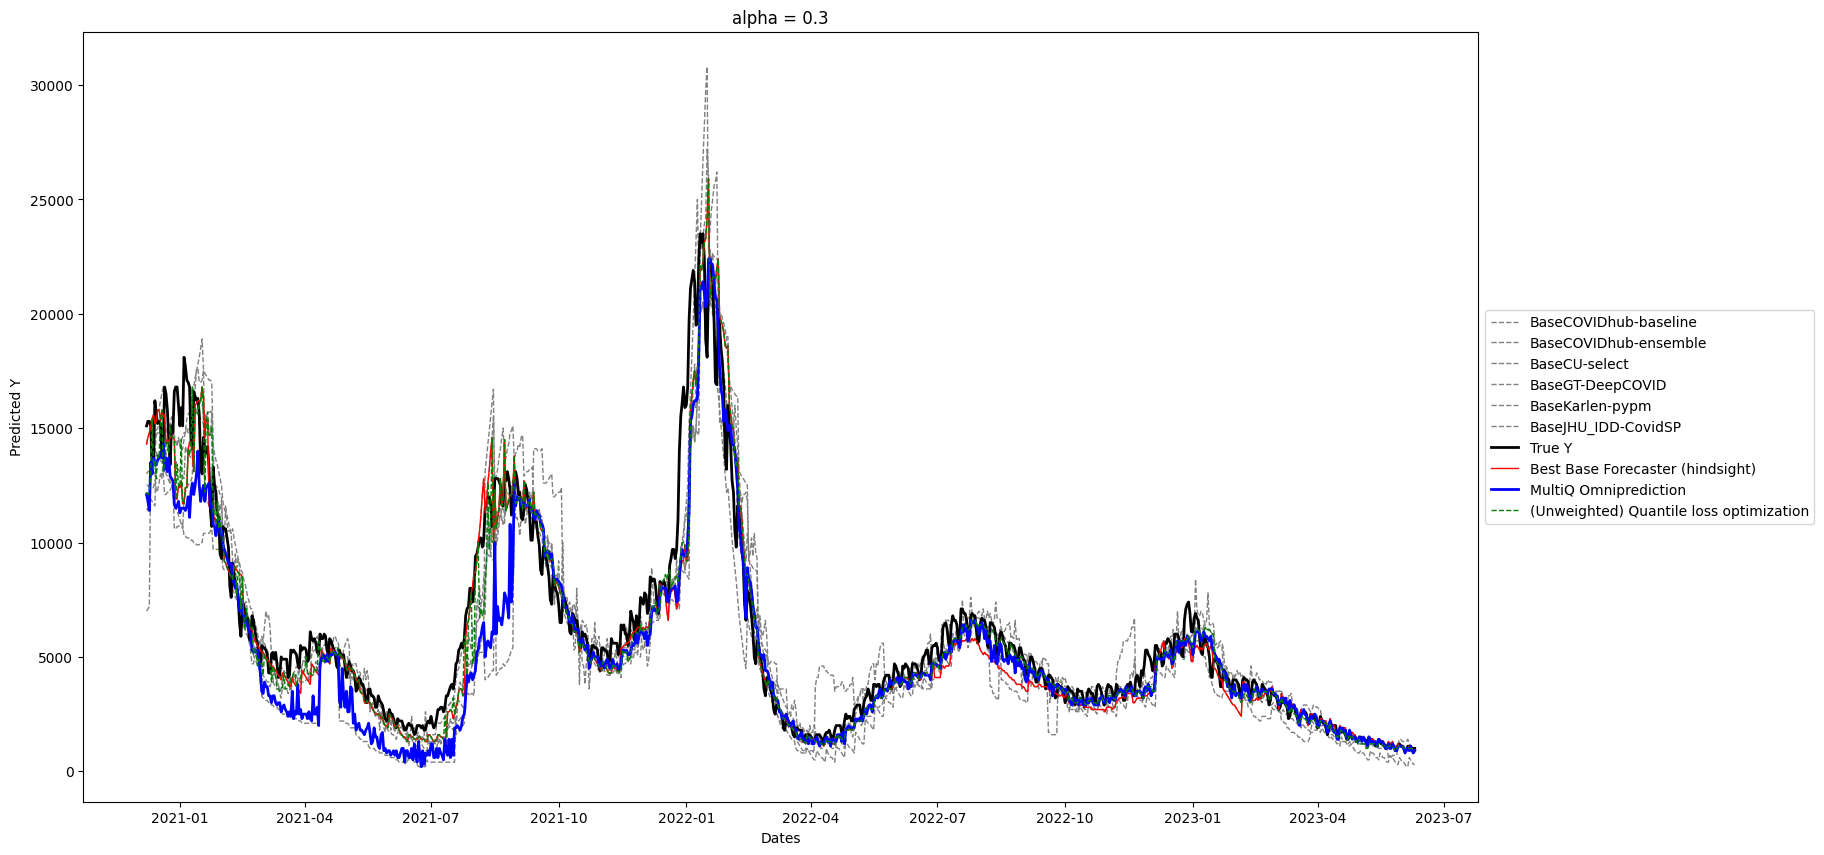

In [77]:
ia = 1
df = pd.DataFrame(
    np.concatenate(
        [
            phat_history[:, ia][:, None],
            forecasters_preds_history[:, ia, :],
            best_val_forecaster_preds[:, ia][:, None], 
            best_test_forecaster_preds[:, ia][:, None],
            pinball_preds_history[:, ia][:, None], 
            ql_preds_history[:, ia][:, None], 
            Y_arr[:, None]
        ], axis=1
    ),
    columns = (['phat'] +
                [f'pred_{i}' for i in range(1, forecasters_preds_history.shape[2] + 1)] +
                ['best_val_pred', 'best_test_pred', 'pinball_pred', 'ql_pred', 'Y']
                )
)
plot_prediction_panel(
    df=df, ia=ia, alpha=alpha_list_here[ia], relative=False, dates_list=dates_list, unit=unit, 
    forecasters_preds_history=forecasters_preds_history, forecaster_names=forecaster_names, F=F, Y_arr=Y_arr
)